In [5]:
# =============================================================================
# Librerias
# =============================================================================
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import signal

In [10]:
# =============================================================================
# Parametros del sistema
# =============================================================================
Ad0_dB = 100                # Ganancia DC en dB
Ad0_veces = 100e3           # Ganancia DC en veces
Avf = 20                    # Ganancia Lazo Cerrado en dB
f1 = 10                     # Polo 1 del LM324
f2 = 5.06e6                 # Polo 2 del LM324
fT = 1e6                    # Frecuencia de cruce

# =============================================================================
# Analisis del VFA simple
# =============================================================================
# Funcion de transferencia Lazo abierto
num = [Ad0_veces * (2 * np.pi)**2 * f1 * f2]
den = [1, 2 * np.pi * (f1 + f2), (2 * np.pi)**2 * f1 * f2]

# =============================================================================
# Analisis del Amplificador Compuesto
# =============================================================================
Ri = 10e3       # Definido manualmente
Rf = 9 * Ri

K = Ri / (Ri + Rf)                  # Magnitud de K en veces
mag_1_K_dB = 20 * np.log10(1 / K)   # Magnitud de 1/K en dB

num_compuesto = np.convolve(num, num)                                       # Numerador del sistema compuesto
den_compuesto = np.convolve(den, den)                                       # Denominador del sistema compuesto
sistema_compuesto = signal.TransferFunction(num_compuesto, den_compuesto)   # Funcion de transferencia del sistema compuesto

fg = fT / np.sqrt(1 / K)            # Ancho de banda potencial (Hz)
# =============================================================================
# Analisis del segundo amplificador operacional (AO2)
# =============================================================================
f_px = fT * np.sqrt(2 * K)      # Frecuencia del polo de AO2 (Hz)

Avf2 = np.sqrt((1 / K) / 2)     # Ganancia del lazo cerrado de AO2 (veces)

# Red de realimentacion de AO2:
R1 = 10e3               # Definido manualmente
R2 = (Avf2 - 1) * R1

# =============================================================================
# Respuesta en frecuencia del sistema
# =============================================================================
rango_f = np.logspace(0, 9, 1000)   # Rango de frecuencias para grafico (1 Hz - 1 GHz)

w, mag, fase = signal.bode(sistema_compuesto, 2 * np.pi * rango_f)  # Diagrama de Bode

# =============================================================================
# Resultados numericos
# =============================================================================
print(f"Ri = {Ri/1e3:.0f} kΩ")
print(f"Rf = {Rf/1e3:.0f} kΩ")
print(f"1/K = {1/K:.0f}")
print(f"Ancho de banda potencial fg = {fg/1e3:.2f} kHz")
print(f"Polo de AO2 = {f_px/1e3:.2f} kHz")
print(f"AVf2 = {Avf2:.2f} veces")
print(f"R1 = {R1/1e3:.0f} kΩ")
print(f"R2 = {R2/1e3:.0f} kΩ")


Ri = 10 kΩ
Rf = 90 kΩ
1/K = 10
Ancho de banda potencial fg = 316.23 kHz
Polo de AO2 = 447.21 kHz
AVf2 = 2.24 veces
R1 = 10 kΩ
R2 = 12 kΩ


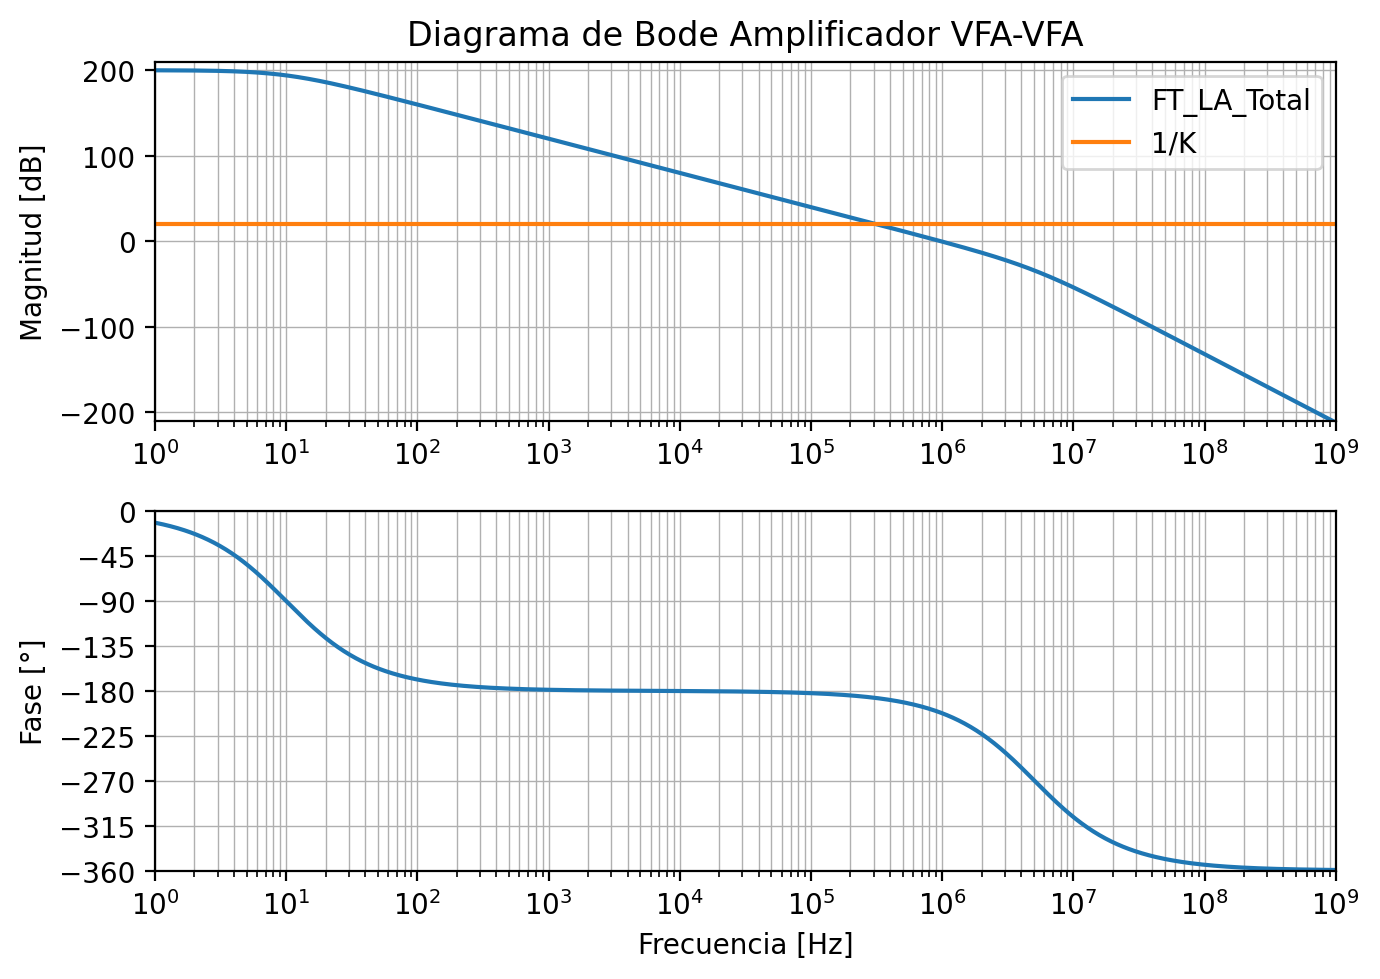

In [14]:
# =============================================================================
# Grafico general
# =============================================================================
plt.figure(figsize=(7, 5), dpi=200)

# Modulo:
plt.subplot(2, 1, 1)
plt.semilogx(rango_f, mag, label='FT_LA_Total')
plt.semilogx(rango_f, [mag_1_K_dB] * len(rango_f), label='1/K') # FT para 1/K
plt.title('Diagrama de Bode Amplificador VFA-VFA')
plt.ylabel('Magnitud [dB]')
plt.xlim(1e0, 1e9)                                              # Limites horizontal: 1 Hz a 1 GHz
plt.ylim(-210, 210)                                             # Limites vertical: -210 dB a 210 dB
plt.grid(which='both', linewidth=0.5)
plt.legend()

# Fase:
plt.subplot(2, 1, 2)
plt.semilogx(rango_f, fase)
plt.ylabel('Fase [°]')
plt.xlabel('Frecuencia [Hz]')
plt.xlim(1e0, 1e9)                                              # Limites horizontal: 1 Hz a 1 GHz
plt.ylim(-360, 0)                                               # Limites vertical: -360 ° a 0 °
plt.yticks(np.arange(-360, 1, 45))                              # Pasos cada 45 °
plt.grid(which='both', linewidth=0.5)

plt.tight_layout()
plt.show()

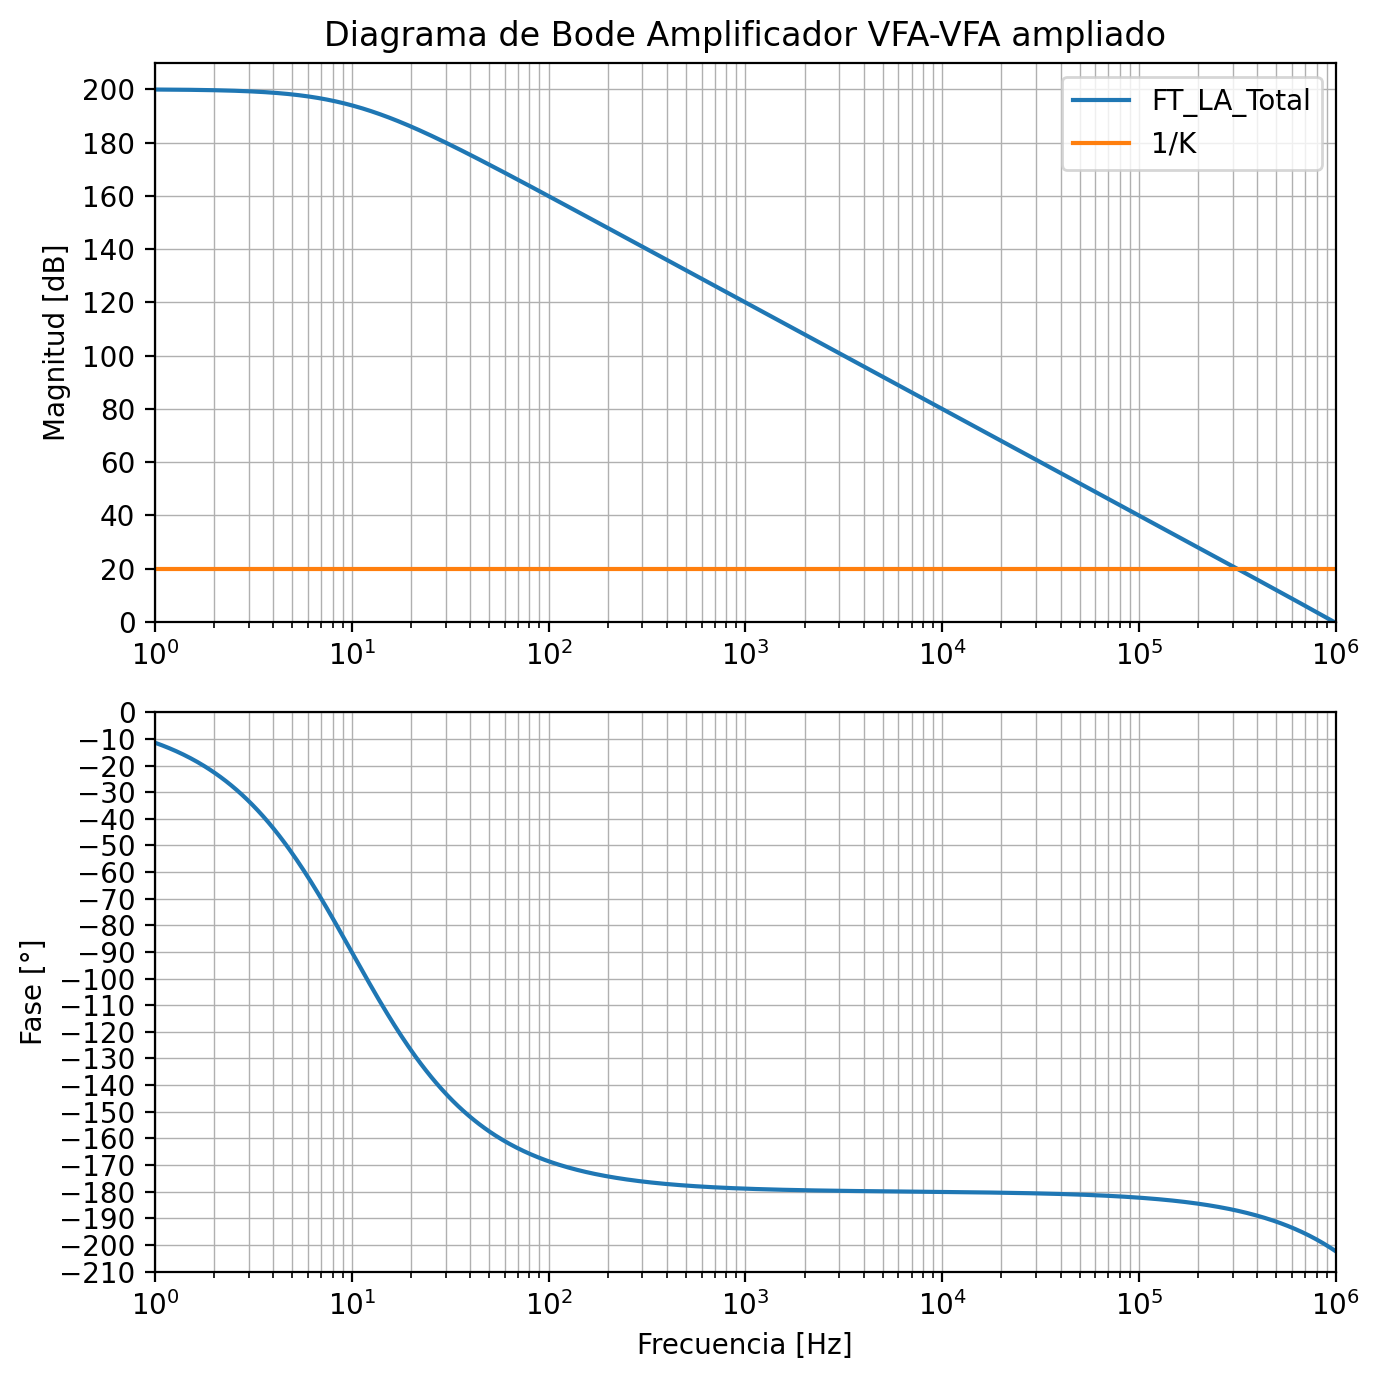

In [13]:
# =============================================================================
# Grafico ampliado
# =============================================================================
plt.figure(figsize=(7, 7), dpi=200)

# Modulo:
plt.subplot(2, 1, 1)
plt.semilogx(rango_f, mag, label='FT_LA_Total')
plt.semilogx(rango_f, [mag_1_K_dB]*len(rango_f), label='1/K')   # FT para 1/K
plt.title('Diagrama de Bode Amplificador VFA-VFA ampliado')
plt.ylabel('Magnitud [dB]')
plt.xlim(1e0, 1e6)                                              # Limites horizontal: 1 Hz a 1 MHz
plt.ylim(0, 210)                                                # Limites vertical: 0 dB a 210 dB
plt.yticks(np.arange(0, 210, 20))                               # Pasos cada 20 dB
plt.grid(which='both', linewidth=0.5)
plt.legend()

# Fase:
plt.subplot(2, 1, 2)
plt.semilogx(rango_f, fase)
plt.ylabel('Fase [°]')
plt.xlabel('Frecuencia [Hz]')
plt.xlim(1e0, 1e6)                                              # Limites horizontal: 1 Hz a 1 GHz
plt.ylim(-210, 0)                                               # Limites vertical: -225 ° a 0 °
plt.yticks(np.arange(-210, 1, 10))                              # Pasos cada 10 °
plt.grid(which='both', linewidth=0.5)

plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# Respuesta al escalon
# =============================================================================
V_pico = 107.69e-3
V_regimen = 96.97e-3

OS = (V_pico - V_regimen) / V_regimen * 100     # Sobrepaso (overshoot) en porcentaje

# Factor de amortiguamiento
ln_os = np.log(OS / 100)
zeta = -ln_os / np.sqrt(np.pi**2 + ln_os**2)

# Margen de fase (grados)
Mp = np.arctan((2 * zeta) / np.sqrt(np.sqrt(1 + 4 * zeta**4) - 2 * zeta**2)) * (180 / np.pi)

print("="*50)
print("Respuesta al escalon")
print("-"*50)
print(f"Sobrepaso (OS) = {OS:.2f} %")
print(f"Zeta = {zeta:.3f}")
print(f"Margen de fase (Mp) = {Mp:.2f}°")

Respuesta al escalon
--------------------------------------------------
Sobrepaso (OS) = 11.05 %
Zeta = 0.574
Margen de fase (Mp) = 57.41°


In [14]:
# =============================================================================
# Respuesta al escalon modificado
# =============================================================================
V_pico = 101.11e-3
V_regimen = 97.86e-3

OS = (V_pico - V_regimen) / V_regimen * 100     # Sobrepaso (overshoot) en porcentaje

# Factor de amortiguamiento
ln_os = np.log(OS / 100)
zeta = -ln_os / np.sqrt(np.pi**2 + ln_os**2)

# Margen de fase (grados)
Mp = np.arctan((2 * zeta) / np.sqrt(np.sqrt(1 + 4 * zeta**4) - 2 * zeta**2)) * (180 / np.pi)

print("="*50)
print("Respuesta al escalon")
print("-"*50)
print(f"Sobrepaso (OS) = {OS:.2f} %")
print(f"Zeta = {zeta:.3f}")
print(f"Margen de fase (Mp) = {Mp:.2f}°")

Respuesta al escalon
--------------------------------------------------
Sobrepaso (OS) = 3.32 %
Zeta = 0.735
Margen de fase (Mp) = 66.93°
